In [31]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from category_encoders import BinaryEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, PolynomialFeatures
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "last_expr" 
%matplotlib inline

In [2]:
data = pd.read_csv('bankloan.csv')
data

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [3]:
print(dir(pd))

['ArrowDtype', 'BooleanDtype', 'Categorical', 'CategoricalDtype', 'CategoricalIndex', 'DataFrame', 'DateOffset', 'DatetimeIndex', 'DatetimeTZDtype', 'ExcelFile', 'ExcelWriter', 'Flags', 'Float32Dtype', 'Float64Dtype', 'Grouper', 'HDFStore', 'Index', 'IndexSlice', 'Int16Dtype', 'Int32Dtype', 'Int64Dtype', 'Int8Dtype', 'Interval', 'IntervalDtype', 'IntervalIndex', 'MultiIndex', 'NA', 'NaT', 'NamedAgg', 'Period', 'PeriodDtype', 'PeriodIndex', 'RangeIndex', 'Series', 'SparseDtype', 'StringDtype', 'Timedelta', 'TimedeltaIndex', 'Timestamp', 'UInt16Dtype', 'UInt32Dtype', 'UInt64Dtype', 'UInt8Dtype', '__all__', '__builtins__', '__cached__', '__doc__', '__docformat__', '__file__', '__git_version__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_built_with_meson', '_config', '_is_numpy_dev', '_libs', '_pandas_datetime_CAPI', '_pandas_parser_CAPI', '_testing', '_typing', '_version_meson', 'annotations', 'api', 'array', 'arrays', 'bdate_range', 'compat', 'conca

In [4]:
dataInfo = data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [5]:
data = data.drop(['ID', 'ZIP.Code'], axis = 1)

In [6]:
data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,0,1,0


In [7]:
data.nunique()

Age                    45
Experience             47
Income                162
Family                  4
CCAvg                 108
Education               3
Mortgage              347
Personal.Loan           2
Securities.Account      2
CD.Account              2
Online                  2
CreditCard              2
dtype: int64

In [8]:
data.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


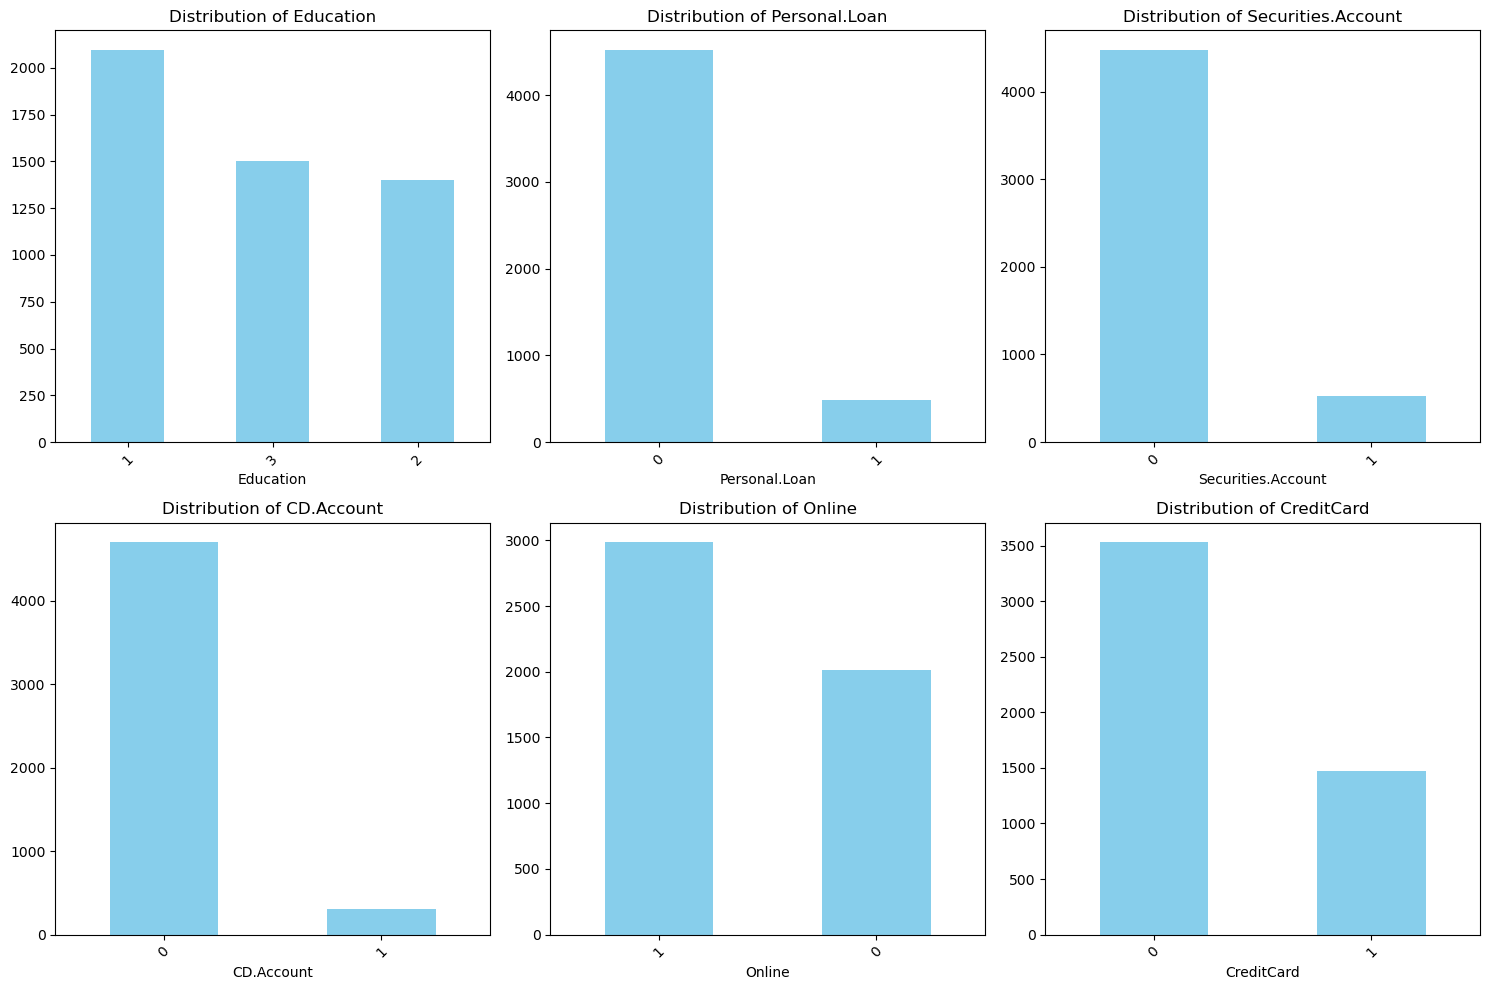

In [9]:
features1 = ['Education', 'Personal.Loan', 'Securities.Account', 
               'CD.Account', 'Online', 'CreditCard']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features1, 1):
    plt.subplot(2, 3, i)
    data[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

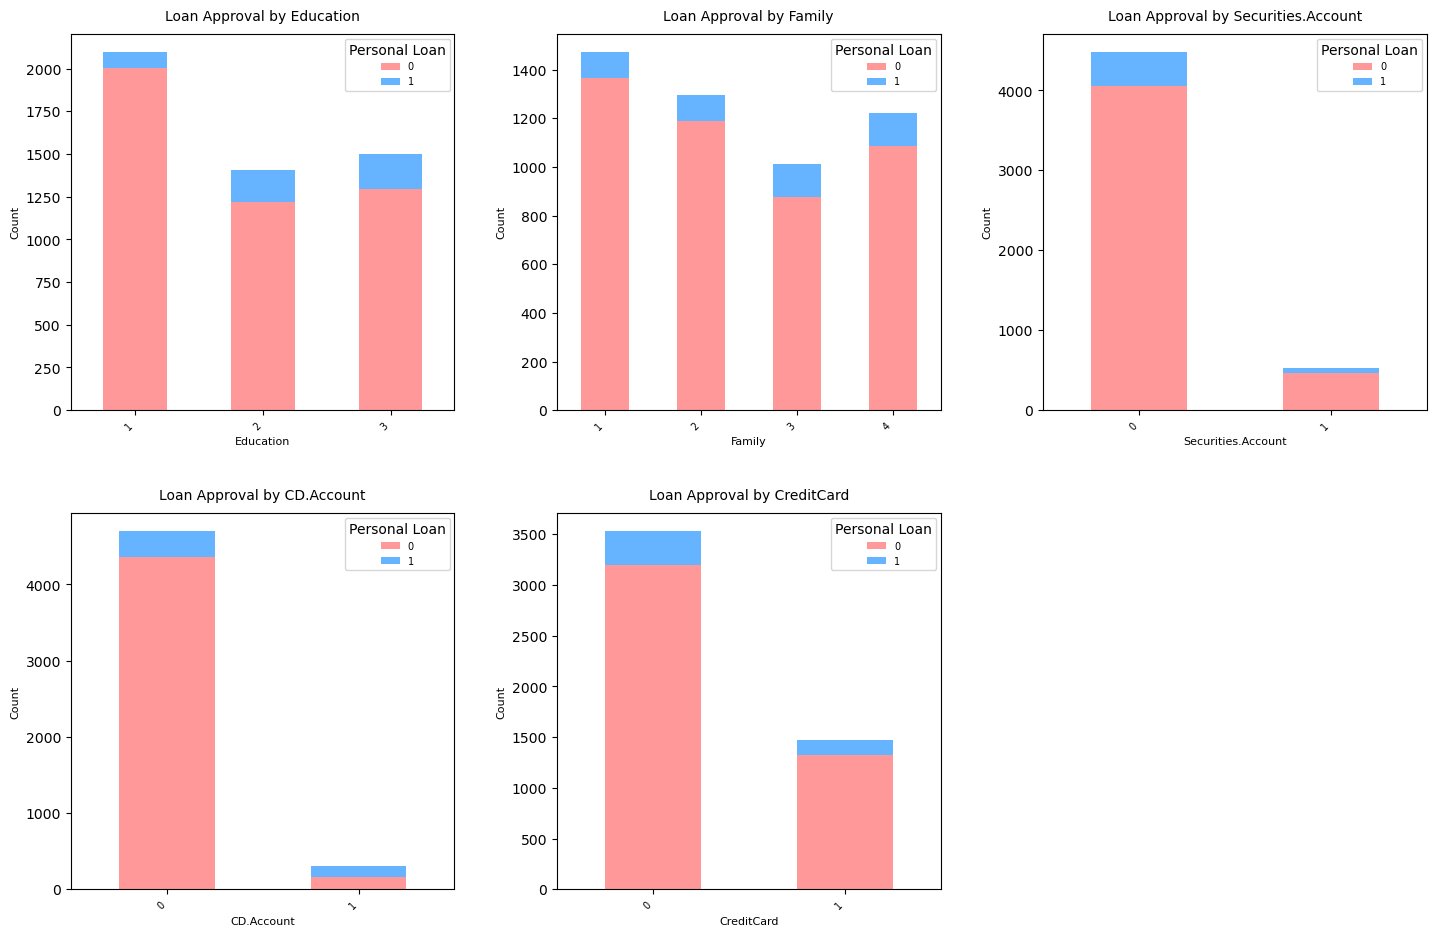

In [41]:
features2 = ['Education', 'Family', 'Securities.Account', 'CD.Account', 'CreditCard']

try:
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Error: 'data' must be a pandas DataFrame")
    if 'Personal.Loan' not in data.columns:
        raise ValueError("Error: 'Personal.Loan' column not found in data")
    if not features2:
        raise ValueError("Error: 'features2' is empty")
    
    # Create figure with adjusted size
    plt.figure(figsize=(15, 10))

    
    for i, col in enumerate(features2[:5], 1):  
        try:
            plt.subplot(2, 3, i)  
            # Compute crosstab and plot
            crosstab = pd.crosstab(data[col], data['Personal.Loan'])
            crosstab.plot(
                kind='bar', 
                stacked=True, 
                color=['#ff9999', '#66b3ff'],
                ax=plt.gca()  # Use current axis
            )
            plt.title(f'Loan Approval by {col}', fontsize=10, pad=10)
            plt.xlabel(col, fontsize=8)
            plt.ylabel('Count', fontsize=8)
            plt.xticks(rotation=45, ha='right', fontsize=7)
            plt.legend(title='Personal Loan', fontsize=7, loc='upper right')
        except Exception as e:
            print(f"Error plotting {col}: {str(e)}")
            continue

    plt.tight_layout(pad=3.0)  # Extra padding
    plt.show()

except Exception as e:
    print(f"Error in setup: {str(e)}")

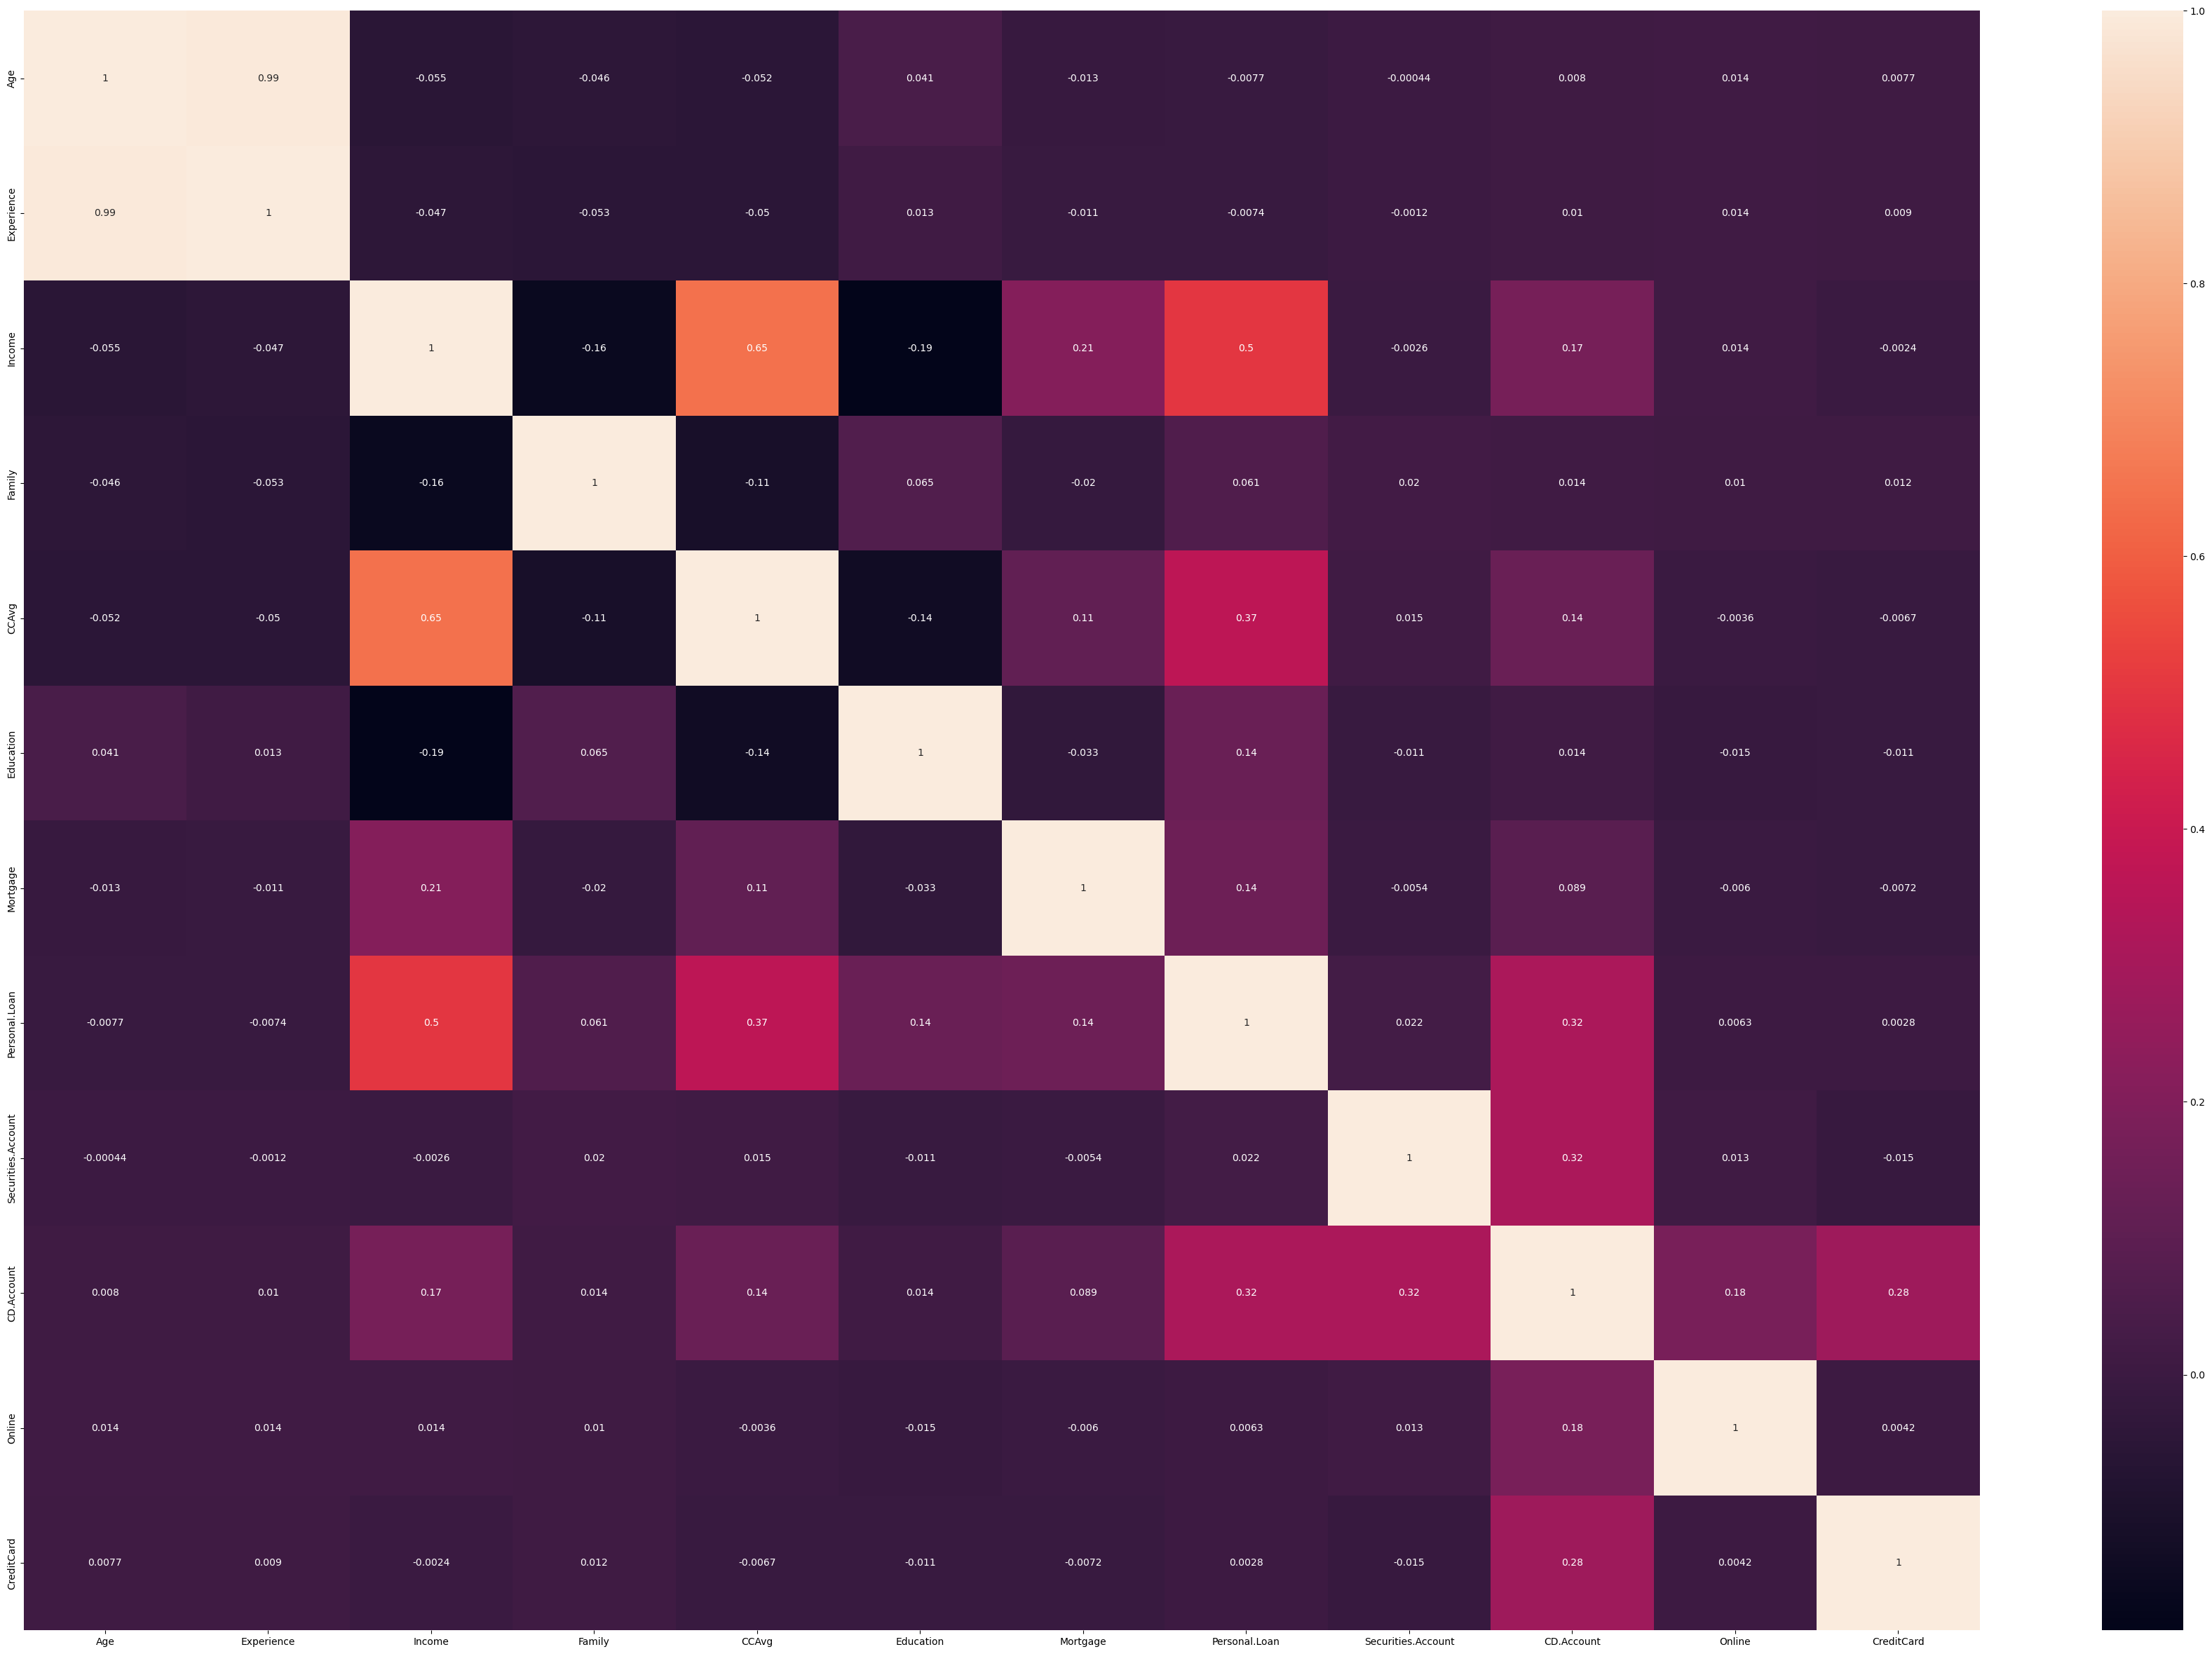

In [11]:
heat_map = data.corr()
plt.figure(figsize = (45, 30))
sns.heatmap(heat_map, annot = True)
plt.show()

In [12]:
train_set, test_set = train_test_split(data, test_size = 0.2, random_state = 42)

In [13]:
train_set

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
4227,32,7,111,1,3.8,1,0,0,1,0,0,0
4676,39,13,68,3,2.1,1,0,0,1,0,1,0
800,31,7,173,1,6.0,1,0,0,0,0,1,0
3671,50,25,18,1,0.4,3,0,0,0,0,1,0
4193,62,37,31,3,0.2,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4426,33,8,140,1,4.6,1,0,0,0,0,1,0
466,25,0,13,2,0.9,3,0,0,0,0,1,0
3092,43,18,113,2,0.4,1,325,0,1,0,0,0
3772,35,10,152,2,3.0,1,0,0,0,0,1,0


In [14]:
def prepare_features_and_target(train_df, test_df, target_column, columns_to_drop=None, scale_features=True):
    """
    Parameters:
    - train_df, test_df: Pre-split DataFrames
    - target_column: Name of target column
    - columns_to_drop: List of columns to remove (e.g., ['ID'])
    - scale_features: Whether to scale features (default: True)
    
    Returns:
    - Processed X_train, X_test
    - y_train, y_test
    - scaler object (or None)
    """
    
    # Create copies to avoid modifying original DataFrames
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    # Separate target
    y_train = train_df.pop(target_column)
    y_test = test_df.pop(target_column)
    
    # Drop specified columns if provided
    if columns_to_drop:
        train_df = train_df.drop(columns=columns_to_drop, errors='ignore')
        test_df = test_df.drop(columns=columns_to_drop, errors='ignore')
    
    # Initialize scaler
    scaler = None
    
    if scale_features:
        scaler = StandardScaler()
        # Convert to DataFrame to preserve column names
        X_train = pd.DataFrame(scaler.fit_transform(train_df), 
                             columns=train_df.columns)
        X_test = pd.DataFrame(scaler.transform(test_df),
                            columns=test_df.columns)
        return X_train, X_test, y_train, y_test, scaler
    
    return train_df, test_df, y_train, y_test, None

In [15]:
X_train, X_test, y_train, y_test, scaler = prepare_features_and_target(
    train_df=train_set,
    test_df=test_set,
    target_column='Personal.Loan',
    scale_features=True
)

In [16]:
X_train

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities.Account,CD.Account,Online,CreditCard
0,-1.158067,-1.136388,0.805872,-1.206542,1.068332,-1.048362,-0.552351,2.892695,-0.252646,-1.222833,-0.646092
1,-0.546673,-0.612697,-0.128441,0.539855,0.096520,-1.048362,-0.552351,2.892695,-0.252646,0.817773,-0.646092
2,-1.245409,-1.136388,2.153022,-1.206542,2.325971,-1.048362,-0.552351,-0.345698,-0.252646,0.817773,-0.646092
3,0.414088,0.434686,-1.214852,-1.206542,-0.875293,1.334279,-0.552351,-0.345698,-0.252646,0.817773,-0.646092
4,1.462191,1.482068,-0.932385,0.539855,-0.989624,-1.048362,-0.552351,-0.345698,-0.252646,0.817773,-0.646092
...,...,...,...,...,...,...,...,...,...,...,...
3995,-1.070725,-1.049106,1.435991,-1.206542,1.525655,-1.048362,-0.552351,-0.345698,-0.252646,0.817773,-0.646092
3996,-1.769460,-1.747361,-1.323493,-0.333344,-0.589466,1.334279,-0.552351,-0.345698,-0.252646,0.817773,-0.646092
3997,-0.197305,-0.176288,0.849329,-0.333344,-0.875293,-1.048362,2.586761,2.892695,-0.252646,-1.222833,-0.646092
3998,-0.896041,-0.874543,1.696729,-0.333344,0.611008,-1.048362,-0.552351,-0.345698,-0.252646,0.817773,-0.646092


In [17]:
y_train

4227    0
4676    0
800     0
3671    0
4193    0
       ..
4426    0
466     0
3092    0
3772    0
860     0
Name: Personal.Loan, Length: 4000, dtype: int64

In [18]:
def logistic_regression_model(X_train, X_test, y_train, y_test, C=1.0, max_iter=100, solver='lbfgs', random_state=42):
    """
    Train a logistic regression model and evaluate its performance.
    
    Parameters:
    -----------
    X_train : array-like
        Training features (already scaled)
    X_test : array-like
        Testing features (already scaled)
    y_train : array-like
        Training labels
    y_test : array-like
        Testing labels
    C : float, default=1.0
        Inverse of regularization strength
    max_iter : int, default=100
        Maximum number of iterations
    solver : str, default='lbfgs'
        Algorithm for optimization
    random_state : int, default=42
        Random seed for reproducibility
        
    Returns:
    --------
    dict
        Dictionary with model and evaluation metrics
    """
    # Create and train model
    model = LogisticRegression(C=C, max_iter=max_iter, solver=solver, random_state=random_state)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }
    
    return metrics

In [19]:
results = logistic_regression_model(X_train, X_test, y_train, y_test)

# Print metrics
print(f"Accuracy: {results['accuracy']:.4f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall: {results['recall']:.4f}")
print(f"ROC AUC: {results['roc_auc']:.4f}")
print("\nConfusion Matrix:")
print(results['confusion_matrix'])
print("\nClassification Report:")
print(results['classification_report'])

Accuracy: 0.9550
Precision: 0.8571
Recall: 0.6857
ROC AUC: 0.9683

Confusion Matrix:
[[883  12]
 [ 33  72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.86      0.69      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.84      0.87      1000
weighted avg       0.95      0.95      0.95      1000



In [20]:
def visualize_model_results(metrics, X_test, y_test, feature_names=None, class_names=['Benign', 'Malignant']):
    """
    Enhanced visualization of logistic regression model performance with professional layout.
    
    Parameters:
    -----------
    metrics : dict
        Dictionary containing model metrics
    X_test : array-like
        Testing features
    y_test : array-like
        Testing labels
    feature_names : list, optional
        Names of features for coefficient visualization
    class_names : list, optional
        Names of target classes
    """
    # Create figure with grid layout
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3)
    
    # Custom color palette
    palette = sns.color_palette("husl", 8)
    
    # 1. Confusion Matrix (Top-left)
    ax1 = fig.add_subplot(gs[0, 0])
    cm_display = ConfusionMatrixDisplay(confusion_matrix=metrics['confusion_matrix'], 
                                      display_labels=class_names)
    cm_display.plot(cmap='Blues', ax=ax1, values_format='d')
    ax1.set_title('Confusion Matrix', pad=20, fontweight='bold')
    
    # 2. ROC Curve (Top-center)
    ax2 = fig.add_subplot(gs[0, 1])
    RocCurveDisplay.from_estimator(
        estimator=metrics['model'],
        X=X_test,
        y=y_test,
        name='Logistic Regression',
        color=palette[2],
        ax=ax2
    )
    ax2.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    ax2.set_title(f'ROC Curve (AUC = {metrics["roc_auc"]:.4f})', pad=20, fontweight='bold')
    ax2.legend(loc='lower right')
    
    # 3. Metrics Radar Chart (Top-right)
    ax3 = fig.add_subplot(gs[0, 2], polar=True)
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
    values = [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1_score']
    ]
    values += values[:1]  # Close the radar chart
    
    angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
    angles += angles[:1]
    
    ax3.fill(angles, values, color=palette[4], alpha=0.25)
    ax3.plot(angles, values, color=palette[4], marker='o')
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics_to_plot)
    ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax3.set_title('Performance Metrics Radar', pad=30, fontweight='bold')
    
    # 4. Feature Importance (Bottom-wide)
    if feature_names is not None:
        ax4 = fig.add_subplot(gs[1, :])
        coefs = metrics['model'].coef_[0]
        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': coefs,
            'Abs_Importance': np.abs(coefs)
        }).sort_values('Abs_Importance', ascending=False).head(10)
        
        colors = [palette[1] if x > 0 else palette[5] for x in feature_importance['Importance']]
        bars = ax4.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
        ax4.set_title('Top 10 Feature Coefficients', pad=20, fontweight='bold')
        ax4.set_xlabel('Coefficient Value')
        ax4.grid(axis='x', linestyle='--', alpha=0.6)
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            label_x = width if width > 0 else width
            ax4.text(label_x, bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}',
                    va='center', ha='left' if width > 0 else 'right',
                    color='black')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
    
    # Print classification report in console
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT".center(60))
    print("="*60)
    print(metrics['classification_report'])
    print("="*60 + "\n")

    plt.show()
 


                   CLASSIFICATION REPORT                    
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.86      0.69      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.84      0.87      1000
weighted avg       0.95      0.95      0.95      1000




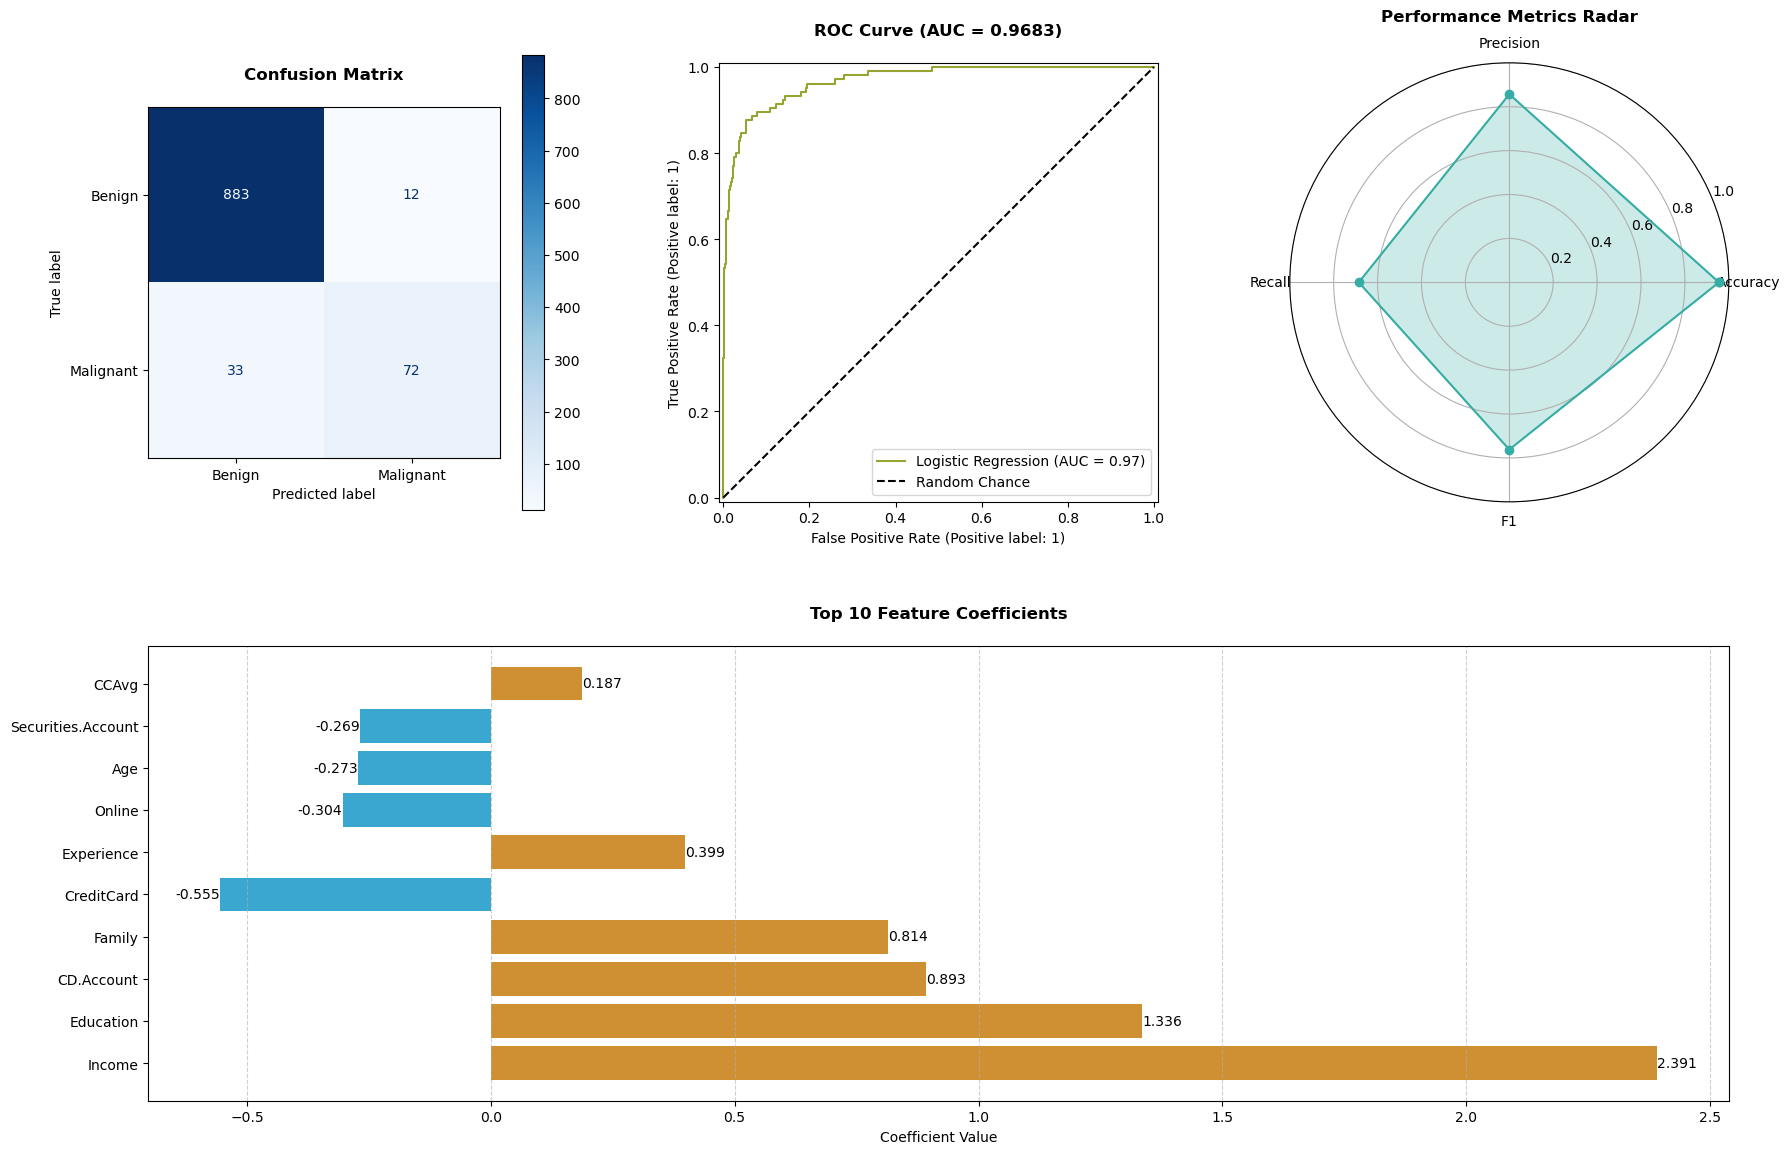

In [21]:
metrics = logistic_regression_model(X_train, X_test, y_train, y_test)
visualize_model_results(metrics, X_test, y_test, feature_names=X_train.columns)


In [22]:
def handle_class_imbalance(X, y, method='smote', random_state=42):
    """
    Handle class imbalance using various resampling techniques.
    
    Parameters:
    -----------
    X : array-like
        Features
    y : array-like
        Target variable
    method : str
        One of: 'smote', 'adasyn', 'oversample', 'undersample', 'smoteenn', 'class_weight'
    random_state : int
        Random seed
        
    Returns:
    --------
    X_resampled, y_resampled or class_weight_dict
    """
    # Calculate original class distribution
    class_counts = np.bincount(y)
    print(f"Original class distribution: {dict(zip(np.unique(y), class_counts))}")
    
    if method == 'smote':
        sampler = SMOTE(random_state=random_state)
    elif method == 'adasyn':
        sampler = ADASYN(random_state=random_state)
    elif method == 'oversample':
        sampler = RandomOverSampler(random_state=random_state)
    elif method == 'undersample':
        sampler = RandomUnderSampler(random_state=random_state)
    elif method == 'smoteenn':
        sampler = SMOTEENN(random_state=random_state)
    elif method == 'class_weight':
        classes = np.unique(y)
        weights = compute_class_weight('balanced', classes=classes, y=y)
        return {'class_weight': dict(zip(classes, weights))}
    else:
        raise ValueError(f"Unknown method: {method}")
    
    X_res, y_res = sampler.fit_resample(X, y)
    print(f"Resampled class distribution: {dict(zip(np.unique(y_res), np.bincount(y_res))}")
    
    return X_res, y_res

SyntaxError: closing parenthesis '}' does not match opening parenthesis '(' (2685129630.py, line 42)

In [43]:
train_set

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
4227,32,7,111,1,3.8,1,0,0,1,0,0,0
4676,39,13,68,3,2.1,1,0,0,1,0,1,0
800,31,7,173,1,6.0,1,0,0,0,0,1,0
3671,50,25,18,1,0.4,3,0,0,0,0,1,0
4193,62,37,31,3,0.2,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4426,33,8,140,1,4.6,1,0,0,0,0,1,0
466,25,0,13,2,0.9,3,0,0,0,0,1,0
3092,43,18,113,2,0.4,1,325,0,1,0,0,0
3772,35,10,152,2,3.0,1,0,0,0,0,1,0
